In [1]:
import pandas as pd
df = pd.read_csv('dataset/raw_collected_data.csv')
df.shape

(24478, 5)

In [2]:
print(df['one_sentence_summary'].isna().sum())
df = df.dropna(subset=['one_sentence_summary'])
df.shape

7502


(16976, 5)

In [3]:
df.head(2)

,urls,titles,keywords,abstracts,one_sentence_summary
0,https://openreview.net/forum?id=Sy8gdB9xx,Understanding deep learning requires rethinkin...,Deep learning,"Despite their massive size, successful deep ar...","Through extensive systematic experiments, we s..."
2,https://openreview.net/forum?id=Hk4_qw5xe,Towards Principled Methods for Training Genera...,NaN,The goal of this paper is not to introduce a s...,We introduce a theory about generative adversa...


In [4]:
print(df['keywords'].isna().sum())
df = df.dropna(subset=['keywords'])
df.shape

400


(16576, 5)

In [6]:
def len_sent(text:str):
    return len(text.split())

df['len_one_sentence_summary'] = df['one_sentence_summary'].apply(len_sent)
df.head(3)

,urls,titles,keywords,abstracts,one_sentence_summary,len_one_sentence_summary
0,https://openreview.net/forum?id=Sy8gdB9xx,Understanding deep learning requires rethinkin...,Deep learning,"Despite their massive size, successful deep ar...","Through extensive systematic experiments, we s...",29
3,https://openreview.net/forum?id=HJ0NvFzxl,Learning Graphical State Transitions,Natural language processing; Deep learning; Su...,Graph-structured data is important in modeling...,I introduce a set of differentiable graph tran...,33
5,https://openreview.net/forum?id=H1W1UN9gg,Deep Information Propagation,Theory; Deep learning,We study the behavior of untrained neural netw...,We predict whether randomly initialized neural...,20


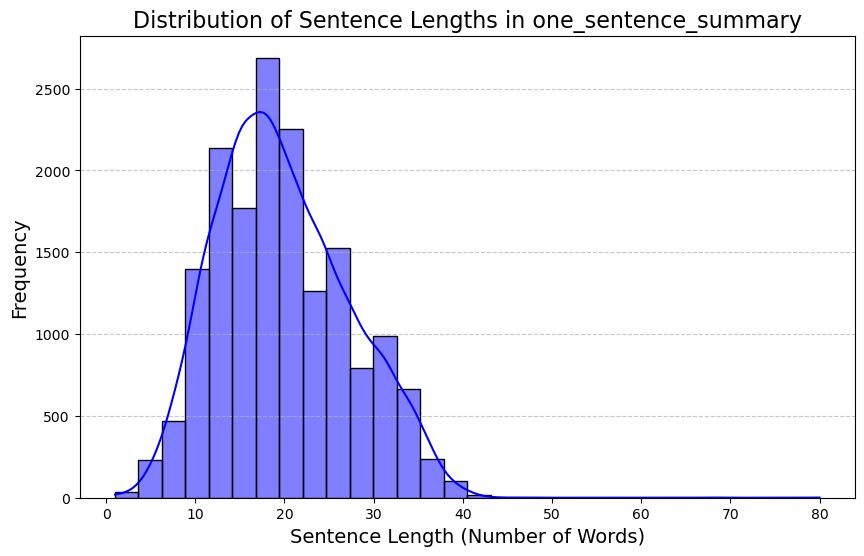

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution using Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df['len_one_sentence_summary'], bins=30, kde=True, color='blue')
plt.title('Distribution of Sentence Lengths in one_sentence_summary', fontsize=16)
plt.xlabel('Sentence Length (Number of Words)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [9]:
# Calculate max, min, and average
max_length = df['len_one_sentence_summary'].max()
min_length = df['len_one_sentence_summary'].min()
average_length = df['len_one_sentence_summary'].mean()

# Print the results
print(f"Maximum Sentence Length: {max_length}")
print(f"Minimum Sentence Length: {min_length}")
print(f"Average Sentence Length: {average_length:.2f}")

# Calculate deciles (Q1 to Q20)
deciles = df['len_one_sentence_summary'].quantile([i / 20 for i in range(1, 21)])
for i, value in enumerate(deciles, start=1):
    print(f"Q{i} ({i * 5}th Percentile): {value}")



Maximum Sentence Length: 80
Minimum Sentence Length: 1
Average Sentence Length: 19.82
Q1 (5th Percentile): 9.0
Q2 (10th Percentile): 11.0
Q3 (15th Percentile): 12.0
Q4 (20th Percentile): 13.0
Q5 (25th Percentile): 14.0
Q6 (30th Percentile): 15.0
Q7 (35th Percentile): 16.0
Q8 (40th Percentile): 17.0
Q9 (45th Percentile): 18.0
Q10 (50th Percentile): 19.0
Q11 (55th Percentile): 20.0
Q12 (60th Percentile): 21.0
Q13 (65th Percentile): 22.0
Q14 (70th Percentile): 23.0
Q15 (75th Percentile): 25.0
Q16 (80th Percentile): 26.0
Q17 (85th Percentile): 28.0
Q18 (90th Percentile): 31.0
Q19 (95th Percentile): 33.0
Q20 (100th Percentile): 80.0


In [10]:
len_range = [15, 40]
prev_df_size = df.shape[0]
df = df[(df['len_one_sentence_summary'] >= len_range[0]) & (df['len_one_sentence_summary'] <= len_range[1])]
print("ignored samples no:", prev_df_size - df.shape[0])
df.shape

ignored samples no: 4289


(12287, 6)

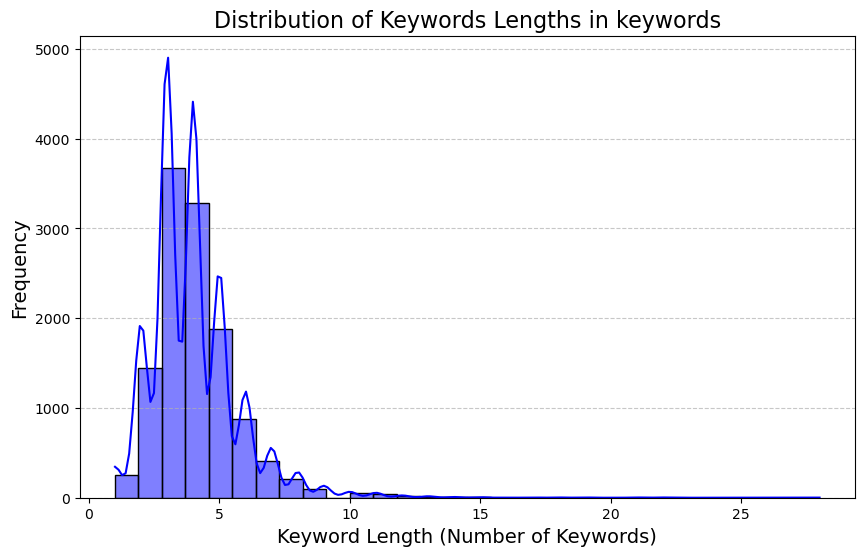

Maximum Keywords Length: 28
Minimum Keywords Length: 1
Average Keywords Length: 4.01
Q1 (5th Percentile): 2.0
Q2 (10th Percentile): 2.0
Q3 (15th Percentile): 3.0
Q4 (20th Percentile): 3.0
Q5 (25th Percentile): 3.0
Q6 (30th Percentile): 3.0
Q7 (35th Percentile): 3.0
Q8 (40th Percentile): 3.0
Q9 (45th Percentile): 4.0
Q10 (50th Percentile): 4.0
Q11 (55th Percentile): 4.0
Q12 (60th Percentile): 4.0
Q13 (65th Percentile): 4.0
Q14 (70th Percentile): 4.0
Q15 (75th Percentile): 5.0
Q16 (80th Percentile): 5.0
Q17 (85th Percentile): 5.0
Q18 (90th Percentile): 6.0
Q19 (95th Percentile): 7.0
Q20 (100th Percentile): 28.0


In [11]:
def len_keywords(text:str):
    return len(text.split(';'))

df['len_keywords'] = df['keywords'].apply(len_keywords)

# Plot the distribution using Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df['len_keywords'], bins=30, kde=True, color='blue')
plt.title('Distribution of Keywords Lengths in keywords', fontsize=16)
plt.xlabel('Keyword Length (Number of Keywords)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate max, min, and average
max_length = df['len_keywords'].max()
min_length = df['len_keywords'].min()
average_length = df['len_keywords'].mean()

# Print the results
print(f"Maximum Keywords Length: {max_length}")
print(f"Minimum Keywords Length: {min_length}")
print(f"Average Keywords Length: {average_length:.2f}")

# Calculate deciles (Q1 to Q20)
deciles = df['len_keywords'].quantile([i / 20 for i in range(1, 21)])
for i, value in enumerate(deciles, start=1):
    print(f"Q{i} ({i * 5}th Percentile): {value}")



In [15]:
len_range = [2, 7]
prev_df_size = df.shape[0]
df = df[(df['len_keywords'] >= len_range[0]) & (df['len_keywords'] <= len_range[1])]
print("ignored samples no:", prev_df_size - df.shape[0])
df.shape

ignored samples no: 712


(11575, 7)

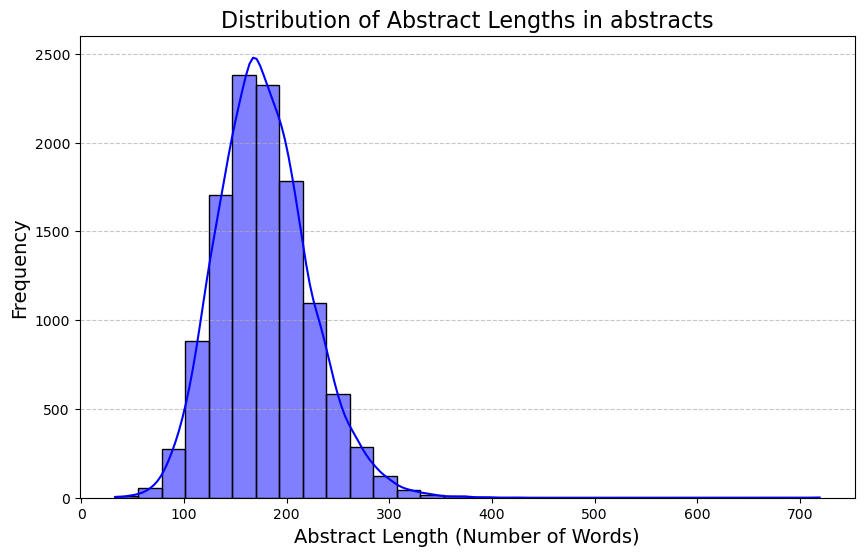

Maximum Abstracts Length: 719
Minimum Abstracts Length: 33
Average Abstracts Length: 178.17
Q1 (5th Percentile): 110.0
Q2 (10th Percentile): 123.0
Q3 (15th Percentile): 133.0
Q4 (20th Percentile): 141.0
Q5 (25th Percentile): 147.0
Q6 (30th Percentile): 153.0
Q7 (35th Percentile): 159.0
Q8 (40th Percentile): 165.0
Q9 (45th Percentile): 170.0
Q10 (50th Percentile): 175.0
Q11 (55th Percentile): 181.0
Q12 (60th Percentile): 186.0
Q13 (65th Percentile): 192.0
Q14 (70th Percentile): 199.0
Q15 (75th Percentile): 205.0
Q16 (80th Percentile): 213.0
Q17 (85th Percentile): 223.0
Q18 (90th Percentile): 236.0
Q19 (95th Percentile): 256.2999999999993
Q20 (100th Percentile): 719.0


In [16]:
def len_abstract(text:str):
    return len(text.split())

df['len_abstract'] = df['abstracts'].apply(len_abstract)

# Plot the distribution using Seaborn
plt.figure(figsize=(10, 6))
sns.histplot(df['len_abstract'], bins=30, kde=True, color='blue')
plt.title('Distribution of Abstract Lengths in abstracts', fontsize=16)
plt.xlabel('Abstract Length (Number of Words)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate max, min, and average
max_length = df['len_abstract'].max()
min_length = df['len_abstract'].min()
average_length = df['len_abstract'].mean()

# Print the results
print(f"Maximum Abstracts Length: {max_length}")
print(f"Minimum Abstracts Length: {min_length}")
print(f"Average Abstracts Length: {average_length:.2f}")

# Calculate deciles (Q1 to Q20)
deciles = df['len_abstract'].quantile([i / 20 for i in range(1, 21)])
for i, value in enumerate(deciles, start=1):
    print(f"Q{i} ({i * 5}th Percentile): {value}")



In [17]:
len_range = [100, 300]
prev_df_size = df.shape[0]
df = df[(df['len_abstract'] >= len_range[0]) & (df['len_abstract'] <= len_range[1])]
print("ignored samples no:", prev_df_size - df.shape[0])
df.shape

ignored samples no: 401


(11174, 8)

In [18]:
print('Unique titles count:', len(df['titles'].unique()))
df = df.drop_duplicates(subset='titles', keep='first')
df.shape

Unique titles count: 11120


(11120, 8)

In [19]:
df = df.drop(columns=['len_one_sentence_summary', 'len_keywords', 'len_abstract'])

In [20]:
df.to_csv("processed_data.csv", index=False)

In [21]:
from sklearn.model_selection import train_test_split

# Split the DataFrame into train and test sets
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Print the sizes of the train and test sets
print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

Training set size: 8896
Test set size: 2224


In [22]:
train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)